In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# -----------------------
# LOAD DATA
# -----------------------
X_train = pd.read_csv(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\X_train.txt", sep='\s+', header=None)
X_test  = pd.read_csv(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\X_test.txt", sep='\s+', header=None)

y_train = pd.read_csv(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\y_train.txt", header=None)
y_test  = pd.read_csv(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\y_test.txt", header=None)

# FIX labels
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print("Shapes:", X_train.shape, X_test.shape)

# -----------------------
# TRAIN RANDOM FOREST
# -----------------------
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

rf.fit(X_train, y_train)

# -----------------------
# PREDICTION
# -----------------------
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# -----------------------
# SAVE MODEL
# -----------------------
joblib.dump(rf, "rf_model.pkl")

print("✅ Random Forest model saved!")

Shapes: (7352, 561) (2947, 561)
Accuracy: 0.9256871394638616
              precision    recall  f1-score   support

           1       0.90      0.96      0.93       496
           2       0.89      0.91      0.90       471
           3       0.96      0.85      0.90       420
           4       0.92      0.89      0.90       491
           5       0.90      0.92      0.91       532
           6       1.00      1.00      1.00       537

    accuracy                           0.93      2947
   macro avg       0.93      0.92      0.92      2947
weighted avg       0.93      0.93      0.93      2947

✅ Random Forest model saved!


In [4]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

with open("rf_report.txt", "w") as f:
    f.write("Random Forest Results\n")
    f.write(report)

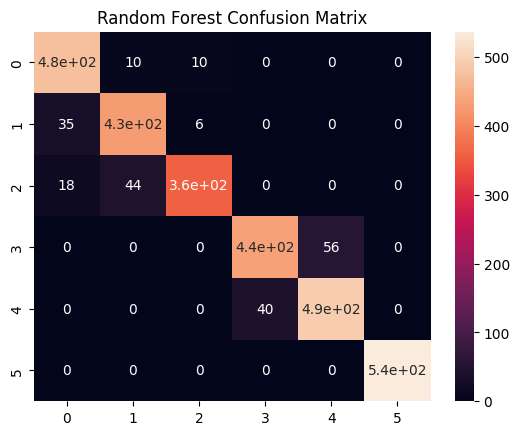

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.title("Random Forest Confusion Matrix")
plt.savefig("plots\confusion_matrix_rf.png")